## **Start**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from helper_functions import protocol_impure as im
from strawberryfields.ops import *
from importlib import reload
def reload_protocols():
    reload(im)

## Displaced Squeezed Thermal States (**DSTS**) - ***Produce*** data

In [4]:
N = 2
num_samples = int(1e9)
mus_grid = np.linspace(0, 1, 201)
beta_grid = np.concatenate([
    np.linspace(0, 0.005, 101, endpoint=False),
    np.linspace(0.005, 1.0, 301)])
sigmas = np.round(np.linspace(0, 1, 51), 2)


In [ ]:
reload_protocols()

for sigma in sigmas:

    print(f"\n σ = {sigma}")
    
    # Compute error probabilities
    perr_dsts = im.perr_dsts(N, mus_grid, beta_grid, sigma, num_samples)
    
    #save data
    np.savez(f"data/DSTS/perr_dsts_b{len(beta_grid)}_mu{len(mus_grid)}_S{num_samples}_N{N}_sigma{sigma}.npz", N=N, beta_grid = beta_grid, mus_grid = mus_grid, perr=perr_dsts, sigma = sigma)


## Displaced Thermal States (**DTS**) - ***Produce*** data

In [ ]:
reload_protocols()

for sigma in sigmas:

    print(f"\n σ = {sigma}")
    
    # Compute error probabilities
    perr_dts = im.perr_dts(N, mus_grid, sigma, num_samples)
    #save data
    np.savez(f"data/DTS/perr_dts_mu{len(mus_grid)}_S{num_samples}_N{N}_sigma{sigma}.npz", N=N, mus_grid = mus_grid, perr=perr_dts, sigma = sigma)


## **Plots** - Homodyne Error Probability

In [2]:
colors_1 = ["#e56ee5",  "#2ca02c",  "#ff7f0e",  "#9467bd",  "#17becf",  "#e377c2",  "#8c564b",  "#bcbd22",  "#7f7f7f",  "#5af74b"]*3
colors_2 = ["#AD0B90",  "#084108",  "#773b05",  "#460880",  "#0c6f7c",  "#5c0642",  "#941c04",  "#8b8b06",  "#212121",  "#092a06",  "#092a06"]*3

In [34]:
reload_protocols()
sigmas_plot = [0.56]
im.plot_homodyne_perr(N, sigmas_plot, colors_1, colors_2, dsts = 'all', dts = 'all')

0.2


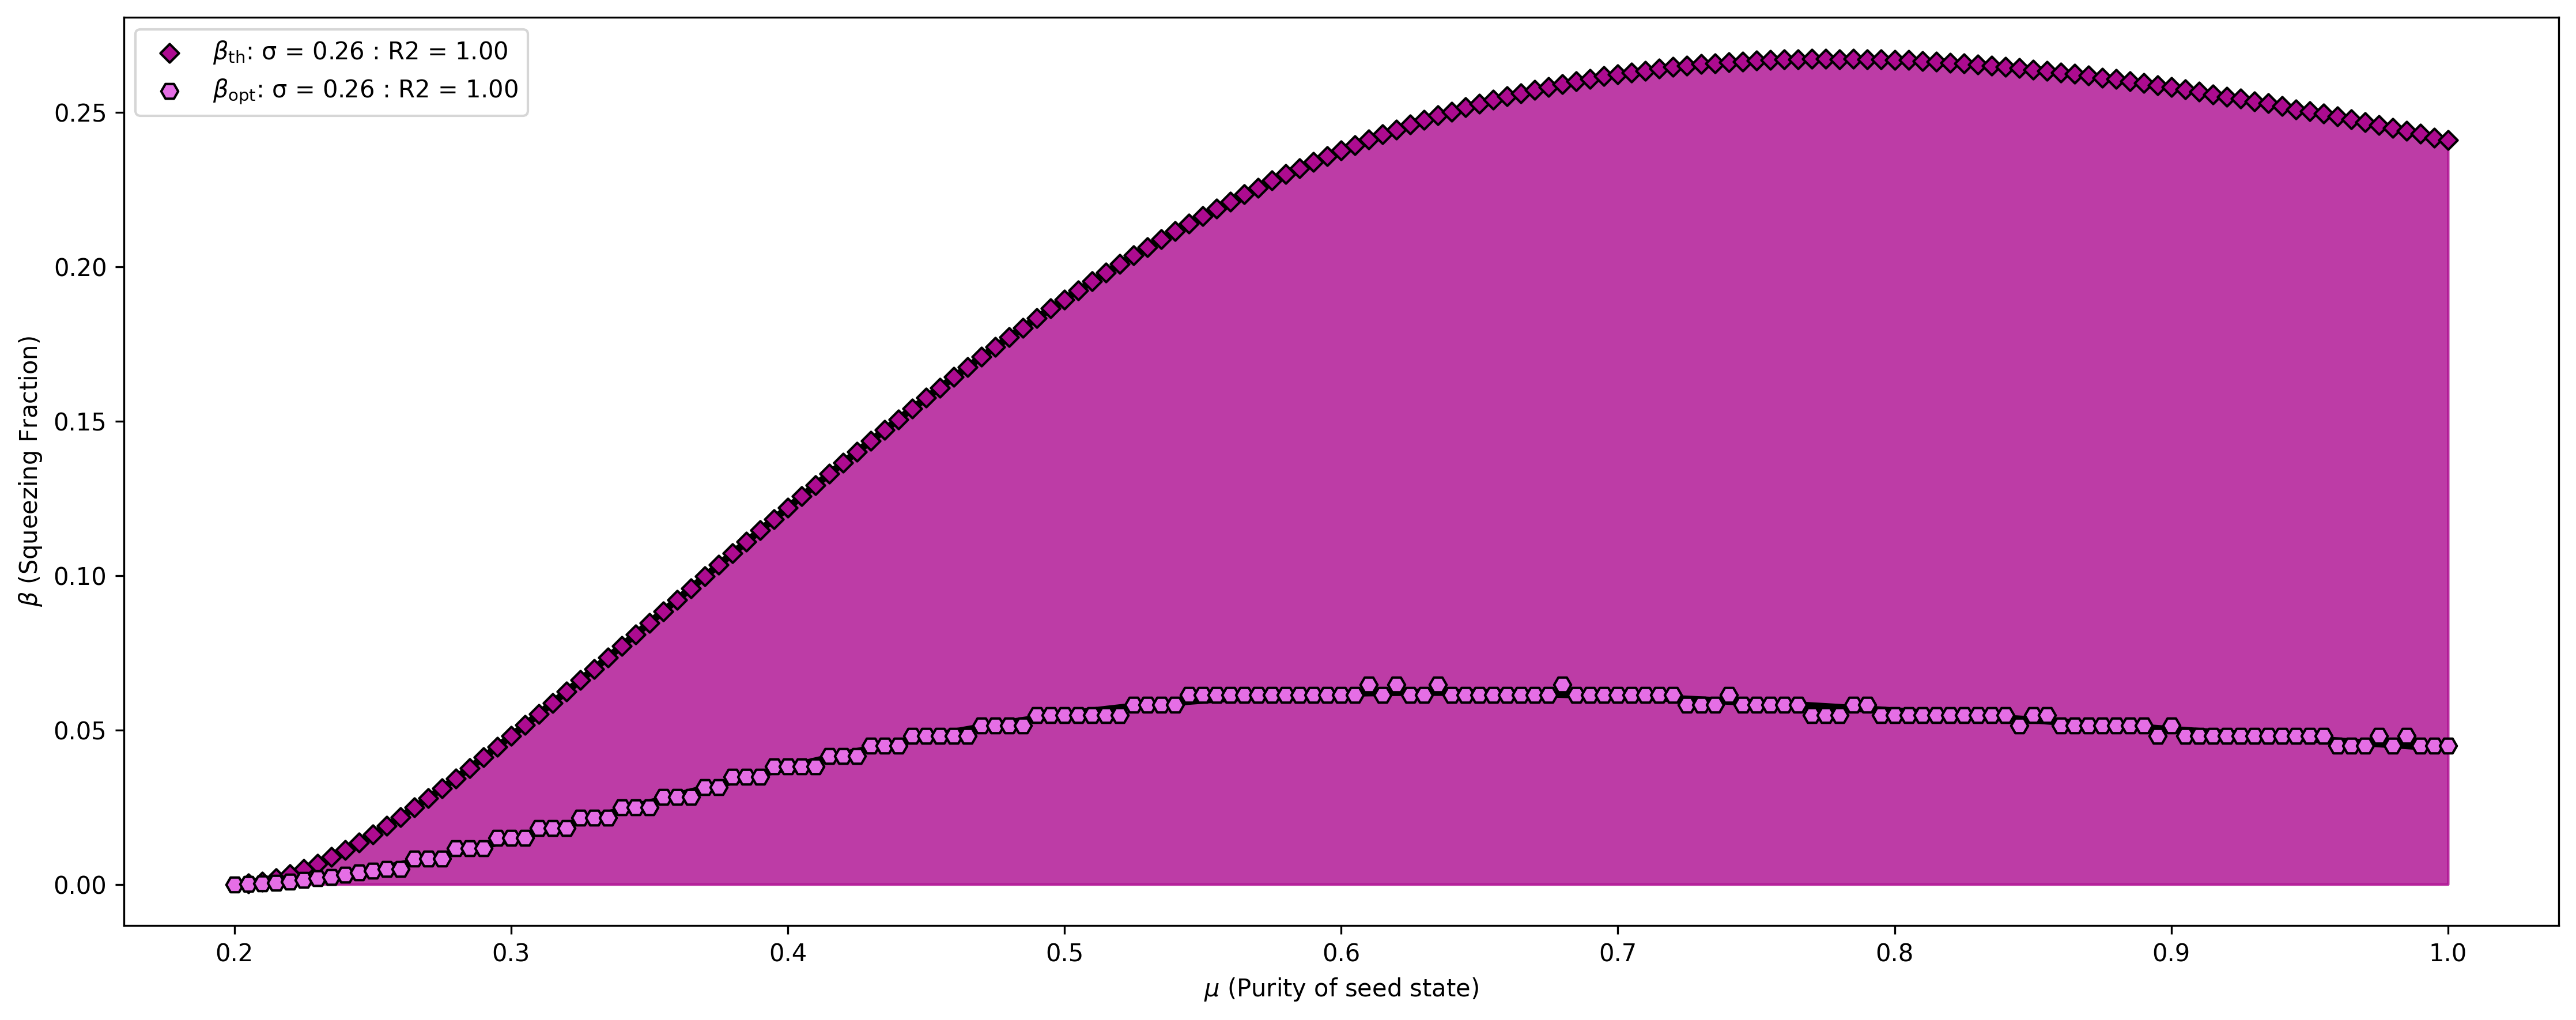

In [40]:
reload_protocols()
sigmas_plot = [0.26]
N=2
im.plot_squeezing(N, sigmas_plot, colors_1, colors_2, opt = True, th = True)

## **Plots** - Beta threshold / optimal 

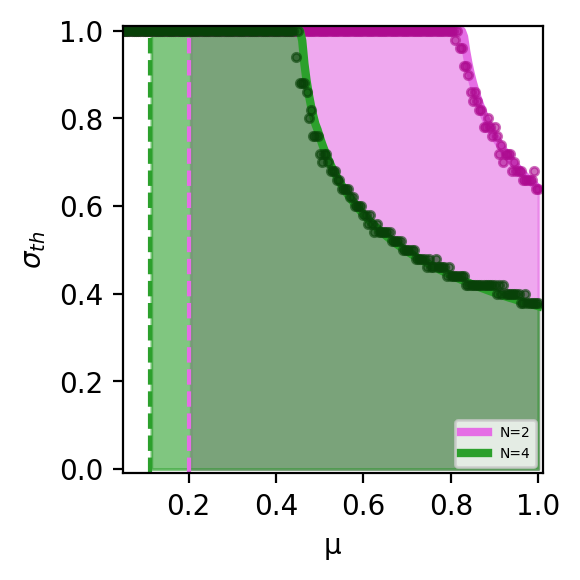

In [27]:
reload_protocols()
N_vals=[2,4]
im.plot_sigma_threshold(N_vals, sigmas, mus_grid, colors_1, colors_2)